<a href="https://colab.research.google.com/github/itto3o/perceptronToCLang/blob/master/6%EC%9E%A5_3%EC%B0%A8%EC%8B%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

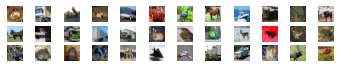

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 30, 30, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 13, 13, 64)       256       
 hNormalization)                                                 
                                                      

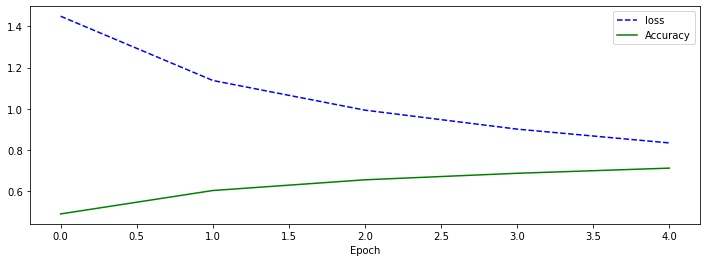

최적화 완료!

======================test result===================
313/313 - 1s - loss: 0.9783 - accuracy: 0.6847 - 1s/epoch - 4ms/step

 Accuracy: 0.6847


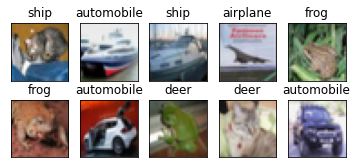

In [3]:
#연습문제 6번 p.220

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#CIFAR-10 데이터를 롣하여 준비. 샘플 값을 정수에서 부동 소수로 변환
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

import matplotlib.pylab as plt

plt.figure(figsize = (6, 1))
for i in range(36) :
  plt.subplot(3, 12, i+1)
  plt.imshow(train_images[i], cmap ="brg") #cmap = "color") #cmap = "gray"였는데 이렇게 해도 되나..? 아 아예 cmap을 주지 않으면 color려나
  plt.axis("off")
plt.show()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truk']

train_images = train_images.reshape((50000, 32, 32, 3)) #채널이 1이 아닌 이유는 color기 때문
test_images = test_images.reshape((10000, 32, 32, 3))
train_images, test_images = train_images / 255.0, test_images / 255.0

#dropout
# model = tf.keras.models.Sequential()
# model.add(tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', strides = (1,1), input_shape=(32, 32, 3)))
# model.add(tf.keras.layers.MaxPooling2D((2, 2)))
# model.add(tf.keras.layers.Dropout(0.25))
# model.add(tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'))
# model.add(tf.keras.layers.MaxPooling2D((2, 2)))
# model.add(tf.keras.layers.Dropout(0.25))
# model.add(tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu'))
# model.add(tf.keras.layers.MaxPooling2D((2, 2)))
# model.add(tf.keras.layers.Dropout(0.25))
# model.add(tf.keras.layers.Flatten())
# model.add(tf.keras.layers.Dense(64, activation='relu'))
# model.add(tf.keras.layers.Dropout(0.25))
# model.add(tf.keras.layers.Dense(10, activation ='softmax'))

#batch normalization
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', strides = (1,1), input_shape=(32, 32, 3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(tf.keras.layers.Flatten())
#여기다 한번 더 넣어야하나..?
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation ='softmax'))

model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, epochs=5, batch_size=10)

plt.figure(figsize=(12, 4))
plt.subplot(1,1,1)
plt.plot(history.history['loss'], 'b--', label='loss')
plt.plot(history.history['accuracy'], 'g-', label='Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()
print('최적화 완료!')

print("\n======================test result===================")
labels = model.predict(test_images)
#verbose = 2로 설정하여 진행막대(progress bar)가 나오지 않도록 설정한다.
print("\n Accuracy: %.4f"%(model.evaluate(test_images, test_labels, verbose=2)[1]))

fig = plt.figure()
for i in range(10) :
  subplot = fig.add_subplot(3, 5, i+1)
  subplot.set_xticks([]) #x축 부 눈금을 제거
  subplot.set_yticks([])
  subplot.set_title('%s'% class_names[np.argmax(labels[i])]) #이런식으로 해도 되는 건가..?
  subplot.imshow(test_images[i].reshape((32, 32,3)), cmap=plt.cm.brg) #cmap=plt.cm.gray_r 안쓰면 되려나?

plt.show()